In [11]:
import sqlite3
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [15]:
DATA_DIR = Path("../data/raw")

df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")
df_v = pd.read_csv(DATA_DIR / "vitalPeriodic.csv")
df_h = pd.read_csv(DATA_DIR / "hospital.csv")

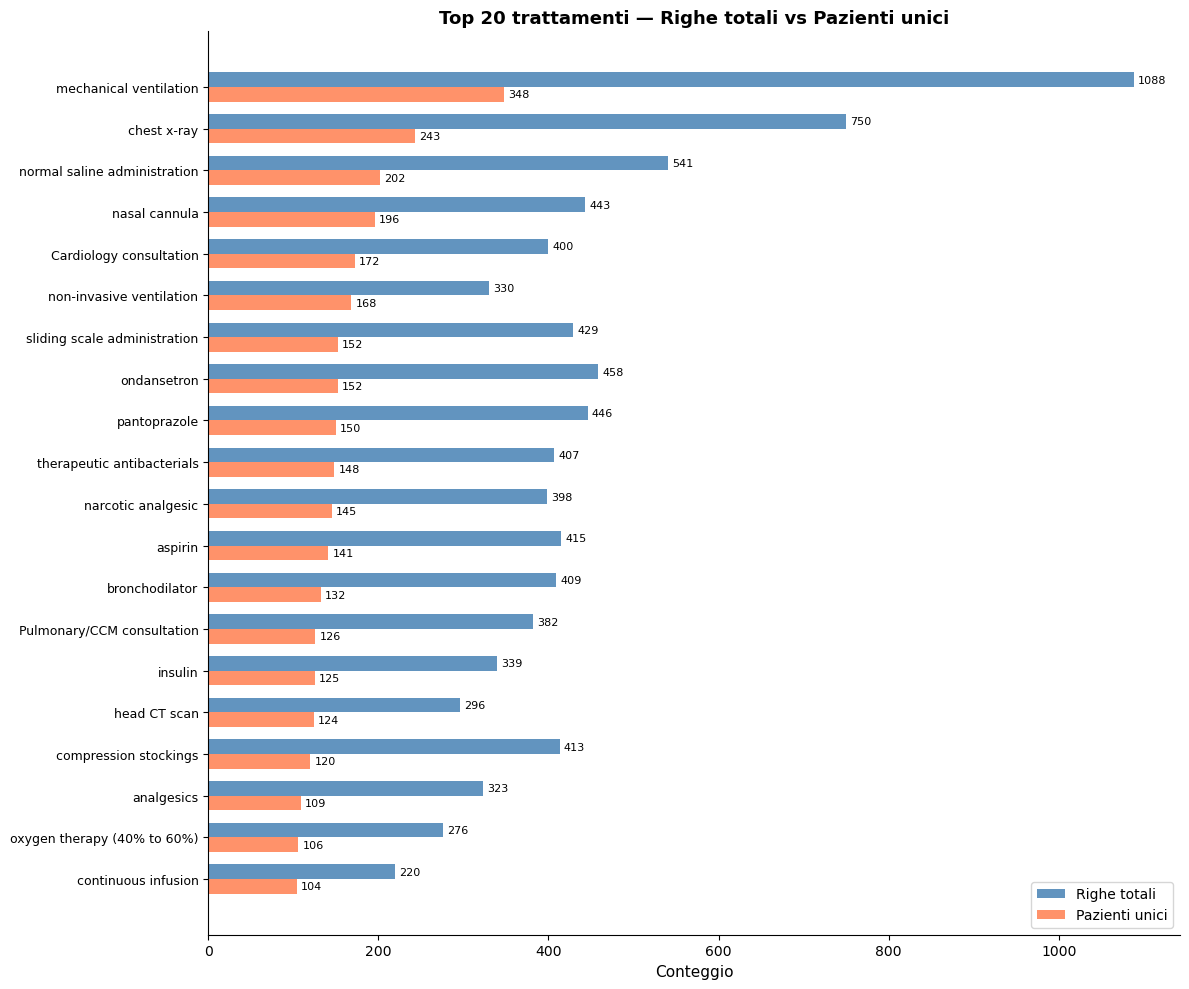

In [14]:
df_counts = pd.DataFrame({
    'righe_totali': df_t['treatmentstring'].value_counts(),
    'pazienti_unici': df_t.groupby('treatmentstring')['patientunitstayid'].nunique()
}).sort_values('pazienti_unici', ascending=True).tail(20)  # top 20

# Accorcia le label (prendi solo l'ultimo livello della gerarchia)
df_counts.index = df_counts.index.str.split('|').str[-1]

fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(df_counts))
height = 0.35

bars1 = ax.barh(
    [i + height/2 for i in y],   #posizione delle barre
    df_counts['righe_totali'],
    height=height,
    label='Righe totali',
    color='steelblue',
    alpha=0.85
)
bars2 = ax.barh(
    [i - height/2 for i in y],
    df_counts['pazienti_unici'],
    height=height,
    label='Pazienti unici',
    color='coral',
    alpha=0.85
)

# Etichette valori
for bar in bars1:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,   #posizione testo centrato e a destra del wigdht
            f'{int(bar.get_width())}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_counts.index, fontsize=9)
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_title('Top 20 trattamenti — Righe totali vs Pazienti unici', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# Calcola metriche per ospedale
hospital_stats = df_p.groupby('hospitalid').agg(
    stay_totali=('patientunitstayid', 'count'),
    pazienti_unici=('uniquepid', 'nunique'),
    tasso_mortalita=('hospitaldischargestatus', lambda x: (x == 'Expired').mean())
).round(3).reset_index()

# Unisci con le info ospedaliere
hospital_stats = hospital_stats.merge(
    df_h[['hospitalid', 'numbedscategory', 'teachingstatus', 'region']],
    on='hospitalid',
    how='left'
)

# Ordina per stay totali
hospital_stats = hospital_stats.sort_values('stay_totali', ascending=False)

print(f"Ospedali totali: {len(hospital_stats)}")
print(f"Tasso mortalità medio: {hospital_stats['tasso_mortalita'].mean():.3f}")
print()
print(hospital_stats.to_string(index=False))


Ospedali totali: 186
Tasso mortalità medio: 0.088

 hospitalid  stay_totali  pazienti_unici  tasso_mortalita numbedscategory teachingstatus    region
        146           40              10            0.050       250 - 499              f      West
        123           30              10            0.067       100 - 249              f     South
        171           25              10            0.120       100 - 249              f      West
        157           25              10            0.280       250 - 499              f      West
        167           24              10            0.000          >= 500              t      West
        155           24              10            0.083       100 - 249              f      West
        154           23              10            0.043       250 - 499              f      West
        310           22              10            0.091       100 - 249              f   Midwest
        243           22              10            0.045 

In [18]:
# Quanti stay totali hai in tutto il dataset?
print(df_p['patientunitstayid'].nunique())

# Quanti pazienti unici?
print(df_p['uniquepid'].nunique())

# Rapporto medio stay/paziente
print(df_p['patientunitstayid'].nunique() / df_p['uniquepid'].nunique())

2520
1841
1.3688212927756653
